# 多资产风险收益分析

本项目比较沪深300ETF、国债ETF、黄金ETF、纳指ETF和恒生ETF的历史风险收益特征。

## 数据获取说明

本项目通过 AkShare 获取东方财富 ETF 日频行情，并使用前复权收盘价。

为减少重复访问数据接口，项目将成功获取的数据保存到本地 `data/raw/` 目录。
后续分析优先读取本地缓存。

由于不同 ETF 的交易日期可能不同，绩效比较使用五只 ETF 同时具有有效价格的共同样本。

In [9]:
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.data import load_price_table

prices, data_summary = load_price_table()

display(data_summary)

print("价格表形状：", prices.shape)
print("开始日期：", prices.index.min())
print("结束日期：", prices.index.max())

print("\n每只 ETF 的缺失值数量：")
print(prices.isna().sum())

display(prices.head())
display(prices.tail())


读取本地缓存：data\raw\510300.csv
读取本地缓存：data\raw\511010.csv
读取本地缓存：data\raw\518880.csv
读取本地缓存：data\raw\513100.csv
读取本地缓存：data\raw\159920.csv


,代码,名称,观测数量,起始日期,结束日期,缺失收盘价,重复日期,非正收盘价
0,510300,沪深300ETF,2674,2015-01-05,2025-12-31,0,0,0
1,511010,国债ETF,2674,2015-01-05,2025-12-31,0,0,0
2,518880,黄金ETF,2674,2015-01-05,2025-12-31,0,0,0
3,513100,纳指ETF,2673,2015-01-05,2025-12-31,0,0,0
4,159920,恒生ETF,2674,2015-01-05,2025-12-31,0,0,0


价格表形状： (2674, 5)
开始日期： 2015-01-05 00:00:00
结束日期： 2025-12-31 00:00:00

每只 ETF 的缺失值数量：
沪深300ETF    0
国债ETF       0
黄金ETF       0
纳指ETF       1
恒生ETF       0
dtype: int64


,沪深300ETF,国债ETF,黄金ETF,纳指ETF,恒生ETF
日期,,,,,
2015-01-05,2.889,98.186,2.414,0.273,1.050
2015-01-06,2.864,98.252,2.435,0.270,1.033
2015-01-07,2.863,98.382,2.445,0.270,1.041
2015-01-08,2.783,98.408,2.431,0.274,1.043
2015-01-09,2.757,98.605,2.439,0.278,1.046


,沪深300ETF,国债ETF,黄金ETF,纳指ETF,恒生ETF
日期,,,,,
2025-12-25,4.643,138.187,9.566,1.930,1.574
2025-12-26,4.661,138.279,9.650,1.929,1.581
2025-12-29,4.640,138.110,9.563,1.916,1.564
2025-12-30,4.650,138.087,9.363,1.914,1.572
2025-12-31,4.630,138.090,9.301,1.904,1.553


In [10]:
prices = prices.sort_index()

print("数据类型：", type(prices))
print("数据形状：", prices.shape)
print("起始日期：", prices.index.min())
print("结束日期：", prices.index.max())
print("日期是否升序：", prices.index.is_monotonic_increasing)

display(prices.head())
display(prices.tail())

数据类型： <class 'pandas.DataFrame'>
数据形状： (2674, 5)
起始日期： 2015-01-05 00:00:00
结束日期： 2025-12-31 00:00:00
日期是否升序： True


,沪深300ETF,国债ETF,黄金ETF,纳指ETF,恒生ETF
日期,,,,,
2015-01-05,2.889,98.186,2.414,0.273,1.050
2015-01-06,2.864,98.252,2.435,0.270,1.033
2015-01-07,2.863,98.382,2.445,0.270,1.041
2015-01-08,2.783,98.408,2.431,0.274,1.043
2015-01-09,2.757,98.605,2.439,0.278,1.046


,沪深300ETF,国债ETF,黄金ETF,纳指ETF,恒生ETF
日期,,,,,
2025-12-25,4.643,138.187,9.566,1.930,1.574
2025-12-26,4.661,138.279,9.650,1.929,1.581
2025-12-29,4.640,138.110,9.563,1.916,1.564
2025-12-30,4.650,138.087,9.363,1.914,1.572
2025-12-31,4.630,138.090,9.301,1.904,1.553


## 1. 数据质量检查与共同样本

不同 ETF 的交易日期可能不完全一致。
为了使不同 ETF 的绩效指标具有可比性，
本项目保留五只 ETF 同时具有有效价格的交易日。

In [11]:
# 缺失值分析
missing_summary = pd.DataFrame({
    "有效价格数量": prices.notna().sum(),
    "缺失价格数量": prices.isna().sum(),
    "缺失比例": prices.isna().mean(),
    "首个有效日期": prices.apply(
        lambda series: series.first_valid_index()
    ),
    # apply对每一列（默认按列）执行这个函数。
    "最后有效日期": prices.apply(
        lambda series: series.last_valid_index()
    ),
})

display(missing_summary)

,有效价格数量,缺失价格数量,缺失比例,首个有效日期,最后有效日期
沪深300ETF,2674,0,0.000000,2015-01-05,2025-12-31
国债ETF,2674,0,0.000000,2015-01-05,2025-12-31
黄金ETF,2674,0,0.000000,2015-01-05,2025-12-31
纳指ETF,2673,1,0.000374,2015-01-05,2025-12-31
恒生ETF,2674,0,0.000000,2015-01-05,2025-12-31


In [12]:
rows_with_missing = prices[prices.isna().any(axis=1)]

print("存在至少一个缺失值的日期数量：", len(rows_with_missing))

display(rows_with_missing.head(10))
display(rows_with_missing.tail(10))

存在至少一个缺失值的日期数量： 1


,沪深300ETF,国债ETF,黄金ETF,纳指ETF,恒生ETF
日期,,,,,
2022-01-13,4.419,122.463,3.654,NaN,1.255


,沪深300ETF,国债ETF,黄金ETF,纳指ETF,恒生ETF
日期,,,,,
2022-01-13,4.419,122.463,3.654,NaN,1.255


In [13]:
print("非正价格数量：")
print((prices <= 0).sum())

print("\n缺失值数量：")
print(prices.isna().sum())

print("\n重复日期数量：")
print(prices.index.duplicated().sum())

非正价格数量：
沪深300ETF    0
国债ETF       0
黄金ETF       0
纳指ETF       0
恒生ETF       0
dtype: int64

缺失值数量：
沪深300ETF    0
国债ETF       0
黄金ETF       0
纳指ETF       1
恒生ETF       0
dtype: int64

重复日期数量：
0


In [14]:
# 寻找共同日期区间
first_valid_dates = prices.apply(
    lambda series: series.first_valid_index()
)

last_valid_dates = prices.apply(
    lambda series: series.last_valid_index()
)

common_start = first_valid_dates.max()
common_end = last_valid_dates.min()

print("共同样本开始日期：", common_start)
print("共同样本结束日期：", common_end)

共同样本开始日期： 2015-01-05 00:00:00
共同样本结束日期： 2025-12-31 00:00:00


In [15]:
# 最终矩阵
prices_common = prices.loc[common_start:common_end].dropna(how="any")

print("共同样本价格形状：", prices_common.shape)
print("共同样本开始日期：", prices_common.index.min())
print("共同样本结束日期：", prices_common.index.max())
print("共同样本缺失值数量：")
print(prices_common.isna().sum())

display(prices_common.head())
display(prices_common.tail())

共同样本价格形状： (2673, 5)
共同样本开始日期： 2015-01-05 00:00:00
共同样本结束日期： 2025-12-31 00:00:00
共同样本缺失值数量：
沪深300ETF    0
国债ETF       0
黄金ETF       0
纳指ETF       0
恒生ETF       0
dtype: int64


,沪深300ETF,国债ETF,黄金ETF,纳指ETF,恒生ETF
日期,,,,,
2015-01-05,2.889,98.186,2.414,0.273,1.050
2015-01-06,2.864,98.252,2.435,0.270,1.033
2015-01-07,2.863,98.382,2.445,0.270,1.041
2015-01-08,2.783,98.408,2.431,0.274,1.043
2015-01-09,2.757,98.605,2.439,0.278,1.046


,沪深300ETF,国债ETF,黄金ETF,纳指ETF,恒生ETF
日期,,,,,
2025-12-25,4.643,138.187,9.566,1.930,1.574
2025-12-26,4.661,138.279,9.650,1.929,1.581
2025-12-29,4.640,138.110,9.563,1.916,1.564
2025-12-30,4.650,138.087,9.363,1.914,1.572
2025-12-31,4.630,138.090,9.301,1.904,1.553


In [16]:
# 共同样本检查
if prices_common.empty:
    raise ValueError("共同样本为空，请检查各 ETF 的日期范围。")

if prices_common.isna().any().any():
    raise ValueError("共同样本仍存在缺失值。")

if (prices_common <= 0).any().any():
    raise ValueError("共同样本存在非正价格。")

if not prices_common.index.is_monotonic_increasing:
    raise ValueError("共同样本日期未按升序排列。")

print("共同样本检查通过。")

共同样本检查通过。


## 2. 收益率与净值

使用共同样本价格计算日简单收益率，并将每日收益率连乘为累计净值。
将第一天作为初始净值1，便于比较不同价格水平的 ETF。

In [17]:
returns = prices_common.pct_change()

valid_returns = returns.dropna(how="all")

wealth = (
    1 + returns.fillna(0)
).cumprod()

print("价格数据形状：", prices_common.shape)
print("收益率数据形状：", returns.shape)
print("有效收益率数据形状：", valid_returns.shape)
print("净值数据形状：", wealth.shape)
print(
    "收益率日期范围：",
    valid_returns.index.min(),
    "至",
    valid_returns.index.max(),
)

display(returns.head())
display(wealth.head())
display(wealth.tail())

价格数据形状： (2673, 5)
收益率数据形状： (2673, 5)
有效收益率数据形状： (2672, 5)
净值数据形状： (2673, 5)
收益率日期范围： 2015-01-06 00:00:00 至 2025-12-31 00:00:00


,沪深300ETF,国债ETF,黄金ETF,纳指ETF,恒生ETF
日期,,,,,
2015-01-05,NaN,NaN,NaN,NaN,NaN
2015-01-06,-0.008654,0.000672,0.008699,-0.010989,-0.016190
2015-01-07,-0.000349,0.001323,0.004107,0.000000,0.007744
2015-01-08,-0.027943,0.000264,-0.005726,0.014815,0.001921
2015-01-09,-0.009342,0.002002,0.003291,0.014599,0.002876


,沪深300ETF,国债ETF,黄金ETF,纳指ETF,恒生ETF
日期,,,,,
2015-01-05,1.000000,1.000000,1.000000,1.000000,1.000000
2015-01-06,0.991346,1.000672,1.008699,0.989011,0.983810
2015-01-07,0.991000,1.001996,1.012842,0.989011,0.991429
2015-01-08,0.963309,1.002261,1.007042,1.003663,0.993333
2015-01-09,0.954309,1.004267,1.010356,1.018315,0.996190


,沪深300ETF,国债ETF,黄金ETF,纳指ETF,恒生ETF
日期,,,,,
2025-12-25,1.607130,1.407400,3.962717,7.069597,1.499048
2025-12-26,1.613361,1.408337,3.997514,7.065934,1.505714
2025-12-29,1.606092,1.406616,3.961475,7.018315,1.489524
2025-12-30,1.609553,1.406382,3.878625,7.010989,1.497143
2025-12-31,1.602631,1.406412,3.852941,6.974359,1.479048


## 3. 绩效指标

计算以下指标：

- 累计收益率
- 年化收益率
- 年化波动率
- 夏普比率
- 最大回撤

夏普比率暂时假设日无风险收益率为 0。
年化因子采用 252 个交易日。

In [18]:
periods_per_year = 252

annualized_return = (
    wealth.iloc[-1]
    ** (periods_per_year / len(valid_returns))
    - 1
)

annualized_volatility = (
    valid_returns.std(ddof=1)
    * np.sqrt(periods_per_year)
)

sharpe_ratio = (
    valid_returns.mean()
    / valid_returns.std(ddof=1)
    * np.sqrt(periods_per_year)
)

running_max = wealth.cummax()
drawdown = wealth / running_max - 1

max_drawdown = drawdown.min()

performance = pd.DataFrame({
    "累计收益率": wealth.iloc[-1] - 1,
    "年化收益率": annualized_return,
    "年化波动率": annualized_volatility,
    "夏普比率": sharpe_ratio,
    "最大回撤": max_drawdown,
})

"""display(
    performance.sort_values(
        "年化收益率",
        ascending=False,
    )
)"""
display(
    performance.style.format({
        "累计收益率": "{:.2%}",
        "年化收益率": "{:.2%}",
        "年化波动率": "{:.2%}",
        "夏普比率": "{:.2f}",
        "最大回撤": "{:.2%}",
    })
)

,累计收益率,年化收益率,年化波动率,夏普比率,最大回撤
沪深300ETF,60.26%,4.55%,26.86%,0.30,-52.97%
国债ETF,40.64%,3.27%,2.44%,1.33,-5.09%
黄金ETF,285.29%,13.57%,13.50%,1.01,-20.47%
纳指ETF,597.44%,20.10%,22.08%,0.94,-28.49%
恒生ETF,47.90%,3.76%,21.87%,0.28,-47.31%


In [19]:
drawdown_summary = pd.DataFrame({
    "最大回撤": drawdown.min(),
    "最大回撤日期": drawdown.idxmin(),
})

display(drawdown_summary)

peak_dates = {}

for column in wealth.columns:
    trough_date = drawdown[column].idxmin()
    peak_date = wealth[column].loc[:trough_date].idxmax()
    peak_dates[column] = peak_date

peak_dates = pd.Series(peak_dates, name="回撤起点")

display(peak_dates)

,最大回撤,最大回撤日期
沪深300ETF,-0.529723,2016-01-28
国债ETF,-0.050873,2020-09-07
黄金ETF,-0.204660,2021-03-05
纳指ETF,-0.284863,2020-03-18
恒生ETF,-0.473105,2022-10-28


沪深300ETF   2015-06-08
国债ETF      2020-04-30
黄金ETF      2020-08-07
纳指ETF      2020-02-13
恒生ETF      2018-01-24
Name: 回撤起点, dtype: datetime64[us]

## 4. 相关性分析

使用日收益率计算不同 ETF 之间的相关系数。
相关性越低，通常意味着组合中可能具有更好的分散化潜力。
但相关性不是固定不变的，且相关性较低不等于一定能够降低未来风险。

In [20]:
correlation = valid_returns.corr()

display(correlation)

,沪深300ETF,国债ETF,黄金ETF,纳指ETF,恒生ETF
沪深300ETF,1.000000,-0.138438,0.010107,0.296461,0.614474
国债ETF,-0.138438,1.000000,0.124408,-0.078316,-0.135450
黄金ETF,0.010107,0.124408,1.000000,-0.040680,-0.019029
纳指ETF,0.296461,-0.078316,-0.040680,1.000000,0.442225
恒生ETF,0.614474,-0.135450,-0.019029,0.442225,1.000000


## 5. 可视化

In [21]:
mpl.rcParams["font.sans-serif"] = [
    "Microsoft YaHei",
    "SimHei",
    "Arial Unicode MS",
]

mpl.rcParams["axes.unicode_minus"] = False

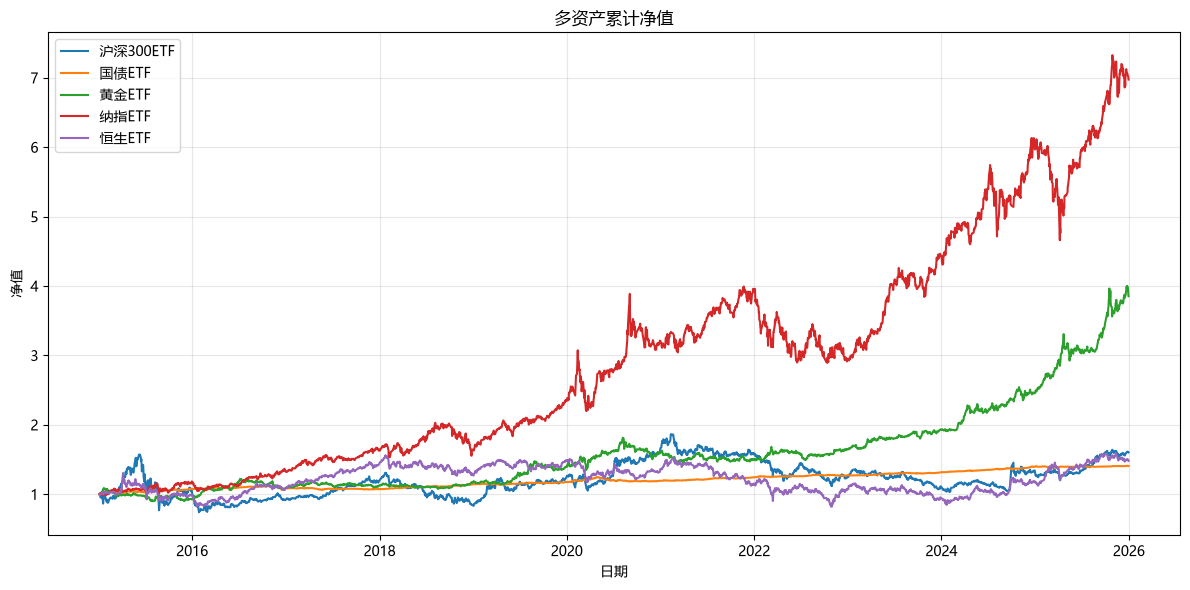

In [22]:
# 绘制累计净值曲线
plt.figure(figsize=(12, 6))

for column in wealth.columns:
    plt.plot(
        wealth.index,
        wealth[column],
        label=column,
    )

plt.title("多资产累计净值")
plt.xlabel("日期")
plt.ylabel("净值")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

plt.savefig(
    output_dir / "cumulative_wealth.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

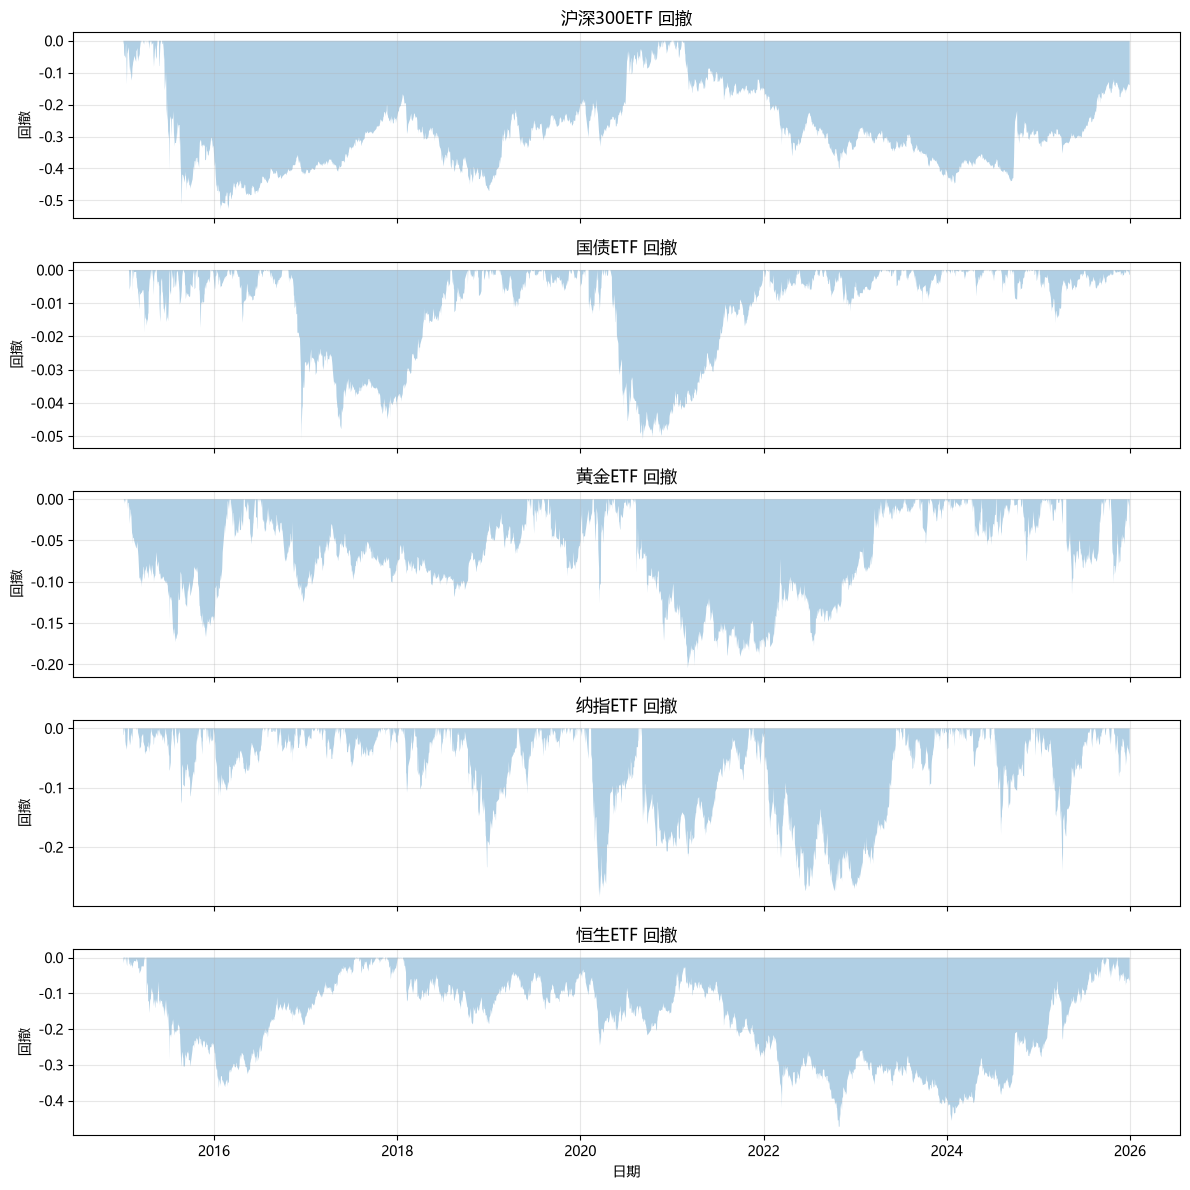

In [23]:
# 绘制回撤曲线
fig, axes = plt.subplots(
    nrows=len(drawdown.columns),
    ncols=1,
    figsize=(12, 12),
    sharex=True,
)

for ax, column in zip(axes, drawdown.columns):
    ax.fill_between(
        drawdown.index,
        drawdown[column],
        0,
        alpha=0.35,
    )
    ax.set_title(f"{column} 回撤")
    ax.set_ylabel("回撤")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("日期")

plt.tight_layout()

plt.savefig(
    output_dir / "drawdown.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

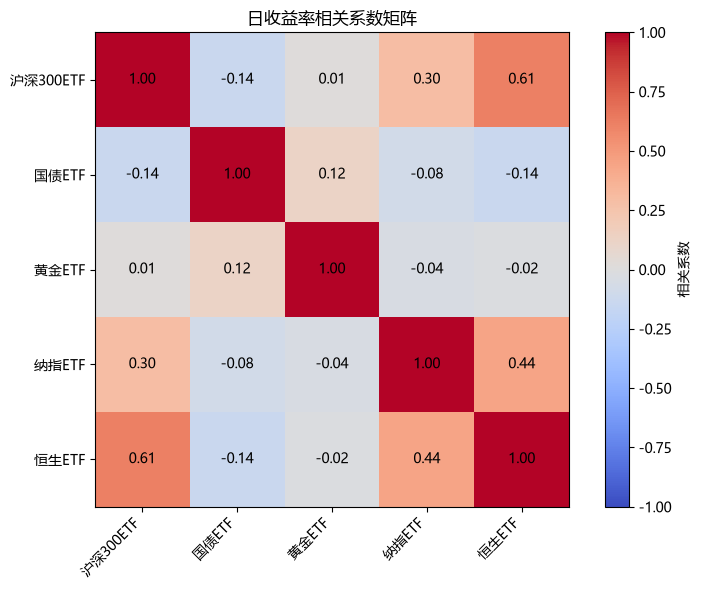

In [24]:
# 绘制相关性热力图
fig, ax = plt.subplots(figsize=(8, 6))

image = ax.imshow(
    correlation,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)

ax.set_xticks(range(len(correlation.columns)))
ax.set_yticks(range(len(correlation.index)))
ax.set_xticklabels(correlation.columns, rotation=45, ha="right")
ax.set_yticklabels(correlation.index)

for i in range(len(correlation.index)):
    for j in range(len(correlation.columns)):
        ax.text(
            j,
            i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center",
        )

ax.set_title("日收益率相关系数矩阵")
fig.colorbar(image, ax=ax, label="相关系数")

plt.tight_layout()

plt.savefig(
    output_dir / "correlation_heatmap.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [25]:
performance.to_csv(
    output_dir / "performance.csv",
    encoding="utf-8-sig",
)

correlation.to_csv(
    output_dir / "correlation.csv",
    encoding="utf-8-sig",
)

drawdown_summary.to_csv(
    output_dir / "drawdown_summary.csv",
    encoding="utf-8-sig",
)

print("分析结果已保存到 outputs/ 目录。")

分析结果已保存到 outputs/ 目录。


In [26]:
print(performance["累计收益率"].equals(wealth.iloc[-1] - 1))
print((performance["累计收益率"] - (wealth.iloc[-1] - 1)).abs().max())

True
0.0
